In [20]:
import np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error



# CSV laden
df = pd.read_csv("agg_full.csv", parse_dates=["order_date"])

# Sortieren für zeitliche Reihenfolge (wichtig!)
df = df.sort_values(by=["coating_id", "order_date"])

df["next_day_fill_rate"] = df.groupby("coating_id")["total_fill_rate"].shift(-1)
df["weekday"] = df["order_date"].dt.weekday  # 0 = Montag
df["month"] = df["order_date"].dt.month
df["day"] = df["order_date"].dt.day

df["rolling_fill_3d"] = df.groupby("coating_id")["total_fill_rate"].transform(lambda x: x.shift(1).rolling(3).mean())
df["rolling_fill_5d"] = df.groupby("coating_id")["total_fill_rate"].transform(lambda x: x.shift(1).rolling(5).mean())
df["rolling_fill_10d"] = df.groupby("coating_id")["total_fill_rate"].transform(lambda x: x.shift(1).rolling(10).mean())
df["rolling_fill_21d"] = df.groupby("coating_id")["total_fill_rate"].transform(lambda x: x.shift(1).rolling(21).mean())

df = df.dropna(subset=["next_day_fill_rate"])



for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)
    elif df[col].dtype == object and set(df[col].dropna().unique()) <= {"True", "False"}:
        df[col] = df[col].map({"False": 0, "True": 1})

# Beispiel: alle numerischen Features außer `total_fill_rate` und Ziel
exclude_cols = ["order_date", "coating_id", "next_day_fill_rate", "total_fill_rate"]
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df["next_day_fill_rate"]

# Beispiel: 'Unknown' → NaN → dann entfernen
X.replace("Unknown", pd.NA, inplace=True)
X = X.dropna()
y = y.loc[X.index]  # Zielvariable mitziehen!

# Train/Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
test_dates = df.loc[X_test.index, "order_date"].copy()

# Modelltraining
model = RandomForestRegressor(n_estimators=3000,
                              max_depth=15,
                              min_samples_split=10,
                              min_samples_leaf=5,
                              random_state=42,
                              n_jobs=-1)
model.fit(X_train, y_train)

# Vorhersage
y_pred = model.predict(X_test)

# Bewertung
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

/var/folders/jt/0j7hbjw96s9b9z0b44wbx9z00000gn/T/ipykernel_73542/2951493382.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.replace("Unknown", pd.NA, inplace=True)


Mean Squared Error: 182.25


In [21]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")

Mean Absolute Error: 5.94


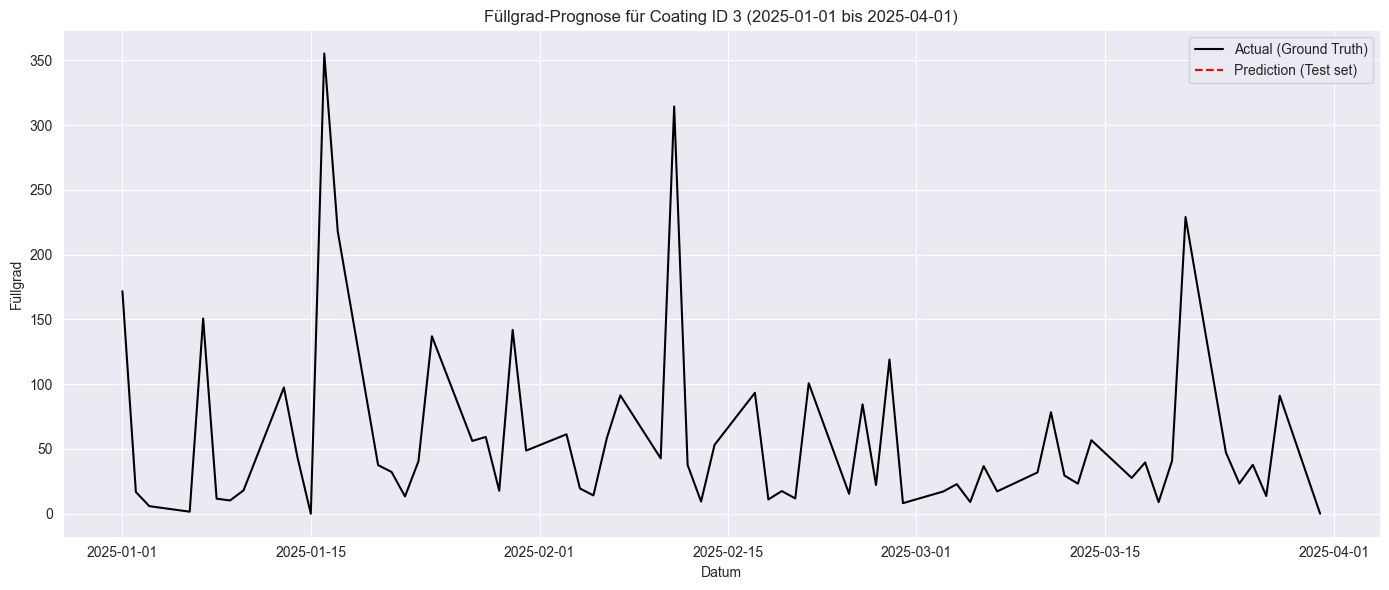

In [23]:
from matplotlib import pyplot as plt
# ---- Choose coating_id to plot ----
chosen_coating_id = 3

# 1. Filter for this coating_id
df_plot = df[df['coating_id'] == chosen_coating_id].copy()

# 2. Add a "split" column to know if each row is train or test
df_plot['split'] = 'train'
df_plot.loc[df_plot['order_date'].isin(test_dates), 'split'] = 'test'

# 3. Get actuals for both train and test
TARGET = "next_day_fill_rate"
df_plot['actual'] = df_plot[TARGET]

# 4. Get predicted values for test set, else NaN
df_plot['pred'] = df['TARGET']  
"""for col in feature_cols:
    if col in df_plot.columns:
        df_plot[col] = df_plot[col].astype(pd.CategoricalDtype(categories=X_train[col].cat.categories))"""
test_index = df_plot.index[df_plot['split']=='test']
df_plot.loc[test_index, 'pred'] = model.predict(df_plot.loc[test_index, feature_cols])

# ---- Zoom for two weeks in Feb 2025 ----
start_date = '2025-01-01'
end_date = '2025-04-01'
mask = (df_plot['order_date'] >= start_date) & (df_plot['order_date'] <= end_date)
df_zoom = df_plot.loc[mask].copy()

plt.figure(figsize=(14, 6))
plt.plot(df_zoom['order_date'], df_zoom['actual'], label='Actual (Ground Truth)', color='black')
plt.plot(df_zoom['order_date'], df_zoom['pred'], label='Prediction (Test set)', color='red', linestyle='--')

if (df_zoom['split'] == 'test').any():
    test_start = df_zoom[df_zoom['split'] == 'test']['order_date'].min()
    plt.axvline(test_start, color='blue', linestyle=':', label='Train/Test Split')

plt.title(f'Füllgrad-Prognose für Coating ID {chosen_coating_id} ({start_date} bis {end_date})')
plt.xlabel('Datum')
plt.ylabel('Füllgrad')
plt.legend()
plt.tight_layout()
plt.show()

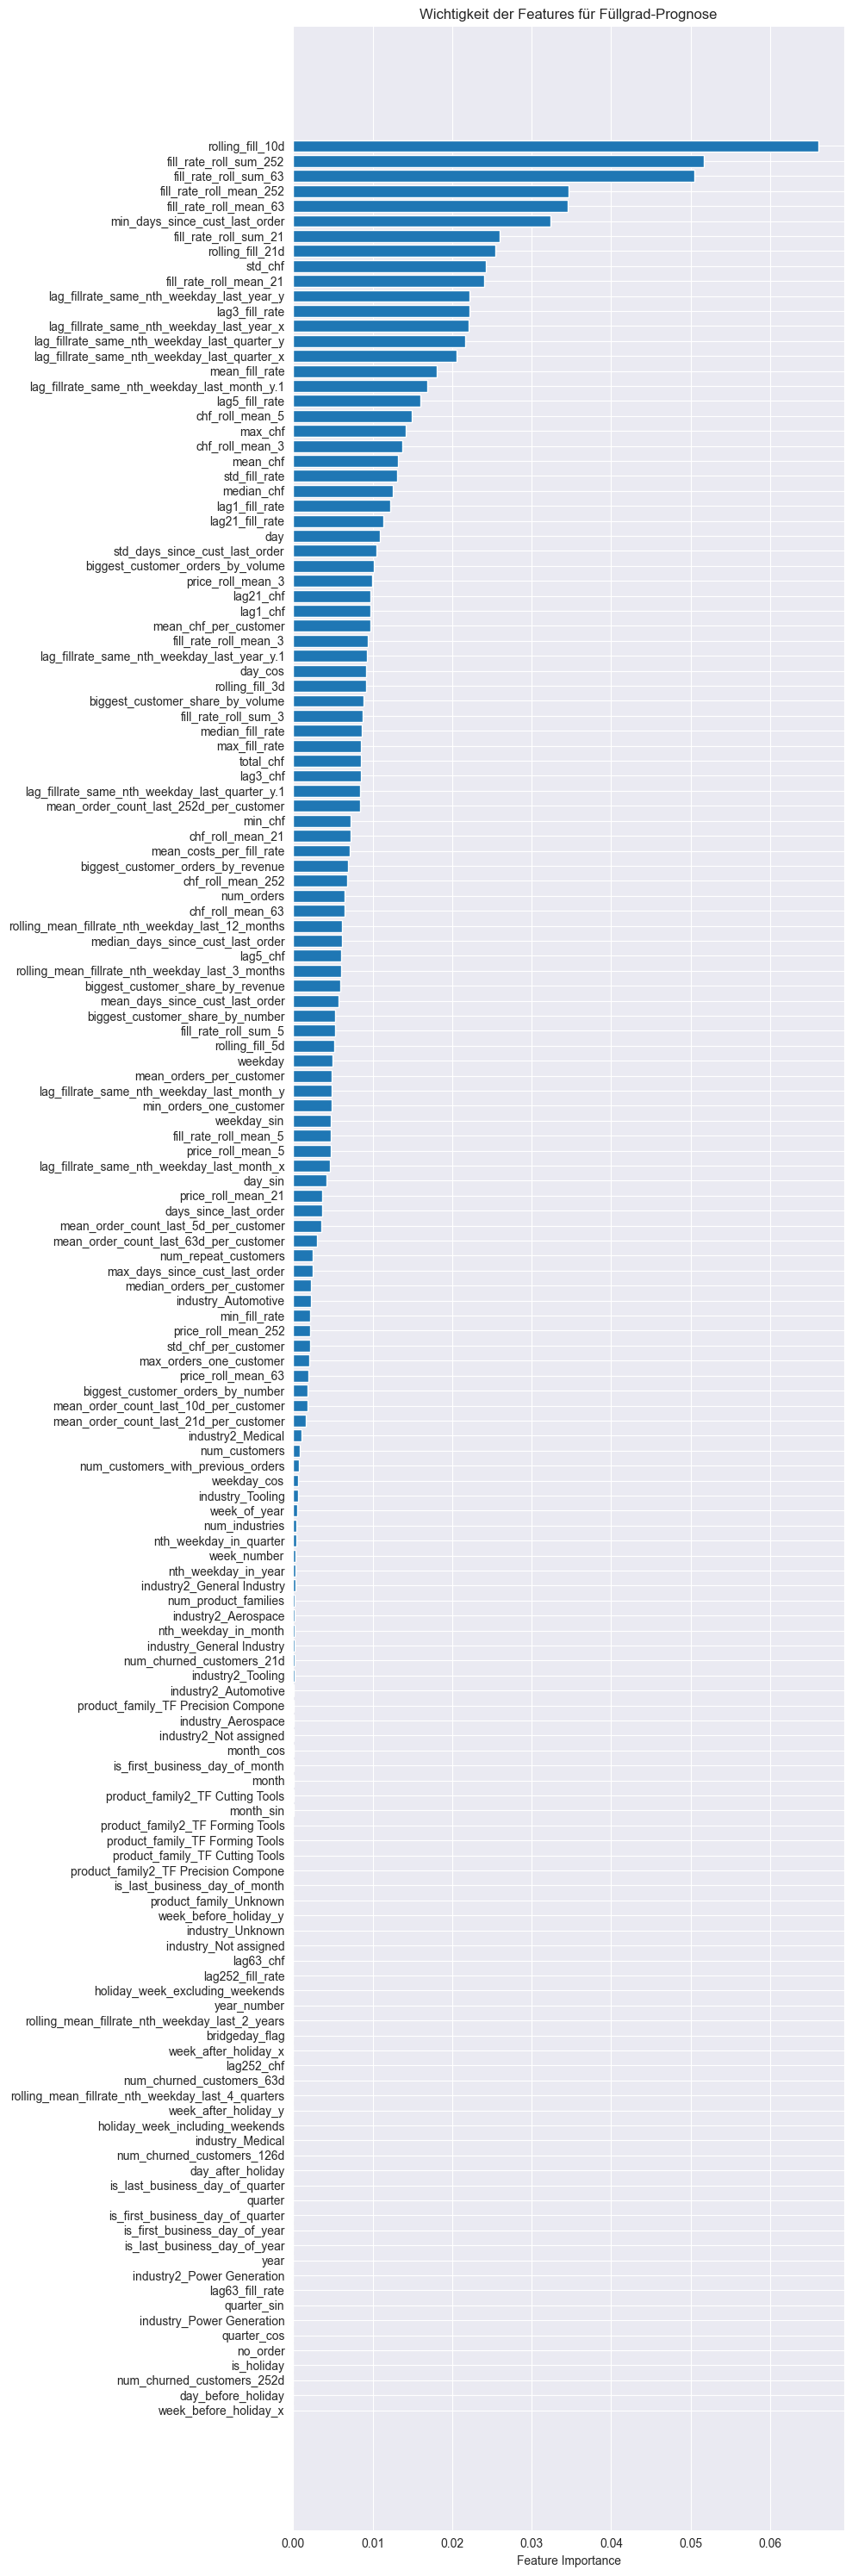

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Feature-Importances extrahieren
importances = model.feature_importances_
feature_names = X.columns

# Nach Wichtigkeit sortieren
indices = np.argsort(importances)[::-1]  # absteigend

# Plot
plt.figure(figsize=(10, 30))
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Wichtigkeit der Features für Füllgrad-Prognose")
plt.gca().invert_yaxis()  # Wichtigstes Feature oben
plt.tight_layout()
plt.show()